# Notebook 19: Complete Deep Learning Workflow

## Problem definition
Build a reproducible multiclass classifier for handwritten digits. We use scikit-learn's built-in 8×8 digits dataset, avoiding external downloads while keeping the whole project quick on CPU. Input is 64 grayscale pixel intensities; target is a digit label from 0 through 9.

Decisions are documented as we go: stratified splits preserve class balance, pixel scaling maps values to [0, 1], logistic regression provides a transparent baseline, and validation metrics select between neural-network configurations. The test set is reserved for final reporting.

## 1. Dataset inspection and EDA
We inspect dimensions, class counts, pixel range, and example images before choosing a small fully connected network. At only 1,797 examples and 8×8 resolution, a large CNN would be unnecessary for this teaching exercise.

Feature matrix: (1797, 64) | labels: (1797,) | pixel range: (np.float32(0.0), np.float32(1.0))
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


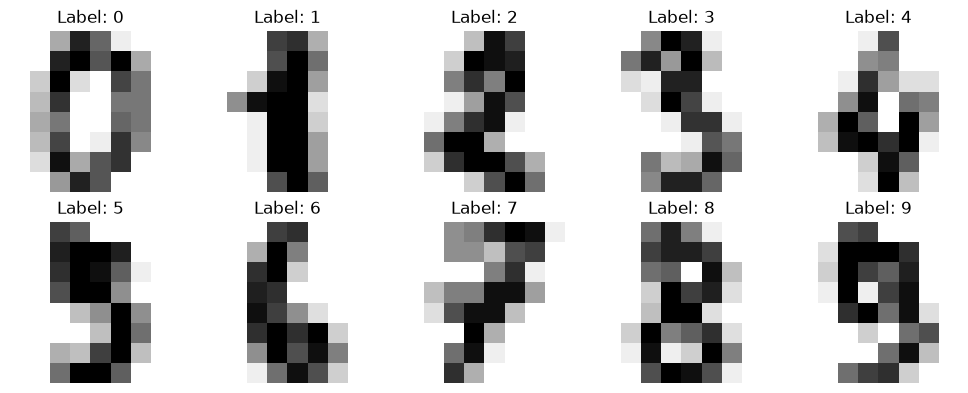

In [1]:
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0; y = digits.target
print('Feature matrix:', X.shape, '| labels:', y.shape, '| pixel range:', (X.min(), X.max()))
print(pd.Series(y).value_counts().sort_index().rename('count'))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flat, digits.images[:10], y[:10]): ax.imshow(image, cmap='gray_r'); ax.set_title(f'Label: {label}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. Preprocessing and train/validation/test split
We split 70%/15%/15% with stratification, so each split retains representative digit classes. Scaling uses the known pixel range; there is no fit statistic to learn. Tensors use float32 features and integer class labels, as expected by `CrossEntropyLoss`.

In [2]:
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
X_train = torch.tensor(X_train_raw, dtype=torch.float32); y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val_raw, dtype=torch.float32); y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test = torch.tensor(X_test_raw, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train, y_train_t), batch_size=64, shuffle=True)
print(f'train={len(y_train)}, validation={len(y_val)}, test={len(y_test)}')

train=1257, validation=270, test=270


## 3. Baseline model
Logistic regression is a strong, fast baseline for this compact dataset. It is less expressive than a neural network, but its performance tells us whether added model complexity is useful.

In [3]:
baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_train_raw, y_train)
baseline_val_accuracy = accuracy_score(y_val, baseline.predict(X_val_raw))
print(f'Logistic regression validation accuracy: {baseline_val_accuracy:.4f}')

Logistic regression validation accuracy: 0.9556


## 4. Neural network, loss, optimizer, and experiments
The MLP maps 64 pixels through configurable hidden layers to 10 class logits. Cross-entropy combines log-softmax and negative log likelihood. We compare a smaller and a larger/dropout configuration, then select by validation accuracy and loss.

The experiment table varies hidden-layer count/width, dropout, learning rate, batch size, optimizer, weight decay, and epochs. It is a compact experiment set, not an exhaustive search.

In [4]:
configs = [
    {'name':'compact Adam', 'widths':[64], 'dropout':0.0, 'lr':0.01, 'batch':64, 'optimizer':'Adam', 'weight_decay':0.0, 'epochs':25},
    {'name':'regularized Adam', 'widths':[128, 64], 'dropout':0.25, 'lr':0.003, 'batch':64, 'optimizer':'Adam', 'weight_decay':1e-4, 'epochs':30}
]

def make_model(config):
    layers = []; in_size = 64
    for width in config['widths']:
        layers.extend([nn.Linear(in_size, width), nn.ReLU()])
        if config['dropout']: layers.append(nn.Dropout(config['dropout']))
        in_size = width
    layers.append(nn.Linear(in_size, 10))
    return nn.Sequential(*layers).to(device)

def fit_config(config):
    model = make_model(config); criterion = nn.CrossEntropyLoss()
    optimizer_class = {'Adam':torch.optim.Adam, 'SGD':torch.optim.SGD}[config['optimizer']]
    optimizer = optimizer_class(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    history = {'train_loss':[], 'val_loss':[], 'train_accuracy':[], 'val_accuracy':[]}
    for epoch in range(config['epochs']):
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad(); loss = criterion(model(features), labels); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            train_logits = model(X_train.to(device)); train_loss = criterion(train_logits, y_train_t.to(device)).item()
            val_logits = model(X_val.to(device)); val_loss = criterion(val_logits, y_val_t.to(device)).item()
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_accuracy'].append((train_logits.argmax(1).cpu() == y_train_t).float().mean().item())
        history['val_accuracy'].append((val_logits.argmax(1).cpu() == y_val_t).float().mean().item())
    return model, history

runs = []
for config in configs:
    model, history = fit_config(config); runs.append({'config':config, 'model':model, 'history':history})
    print(f"{config['name']}: val accuracy={history['val_accuracy'][-1]:.4f}, val loss={history['val_loss'][-1]:.4f}")
results = pd.DataFrame([{'Experiment':r['config']['name'], 'Learning Rate':r['config']['lr'], 'Batch Size':r['config']['batch'],
                          'Architecture':str(r['config']['widths']), 'Optimizer':r['config']['optimizer'],
                          'Accuracy':r['history']['val_accuracy'][-1], 'Loss':r['history']['val_loss'][-1]} for r in runs])
display(results)

compact Adam: val accuracy=0.9630, val loss=0.1264
regularized Adam: val accuracy=0.9630, val loss=0.1261


,Experiment,Learning Rate,Batch Size,Architecture,Optimizer,Accuracy,Loss
0,compact Adam,0.010,64,[64],Adam,0.962963,0.126407
1,regularized Adam,0.003,64,"[128, 64]",Adam,0.962963,0.126081


## 5. Validation curves and model selection
Choose the candidate using validation metrics. If the larger network improves training metrics but not validation metrics, that is evidence of overfitting rather than a reason to prefer it. The curves help distinguish optimization progress from generalization.

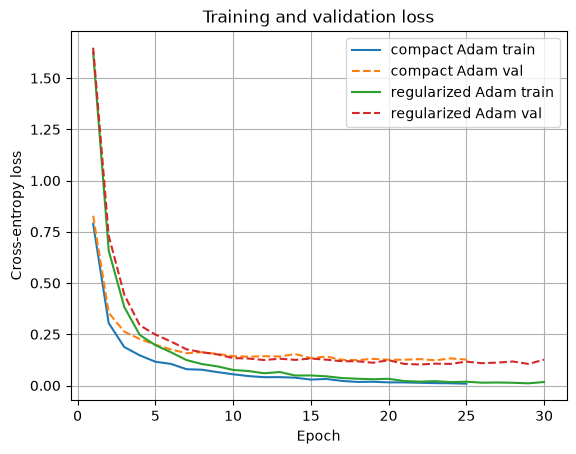

Selected configuration: regularized Adam
Reason: highest validation accuracy, with validation loss breaking ties; verify curves and complexity tradeoff.


In [5]:
for run in runs:
    h = run['history']; epochs = range(1, len(h['train_loss']) + 1)
    plt.plot(epochs, h['train_loss'], label=f"{run['config']['name']} train")
    plt.plot(epochs, h['val_loss'], linestyle='--', label=f"{run['config']['name']} val")
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.title('Training and validation loss'); plt.legend(); plt.grid(True); plt.show()
best_run = max(runs, key=lambda r: (r['history']['val_accuracy'][-1], -r['history']['val_loss'][-1]))
selected_model = best_run['model'].eval()
print('Selected configuration:', best_run['config']['name'])
print('Reason: highest validation accuracy, with validation loss breaking ties; verify curves and complexity tradeoff.')

## 6. Error analysis and final evaluation
The test set is used only after model selection. We report overall and per-class behavior, inspect the confusion matrix and misclassified images, then explain likely causes rather than reporting accuracy alone.

Final test accuracy: 0.9741
              precision    recall  f1-score   support

           0      1.000     0.963     0.981        27
           1      0.848     1.000     0.918        28
           2      0.963     1.000     0.981        26
           3      1.000     1.000     1.000        28
           4      0.964     1.000     0.982        27
           5      1.000     1.000     1.000        27
           6      1.000     1.000     1.000        27
           7      1.000     1.000     1.000        27
           8      1.000     0.769     0.870        26
           9      1.000     1.000     1.000        27

    accuracy                          0.974       270
   macro avg      0.978     0.973     0.973       270
weighted avg      0.977     0.974     0.973       270



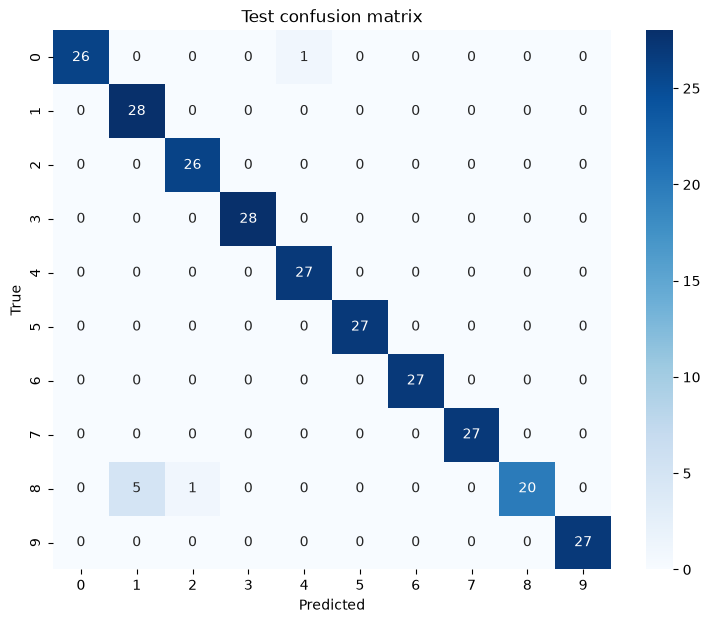

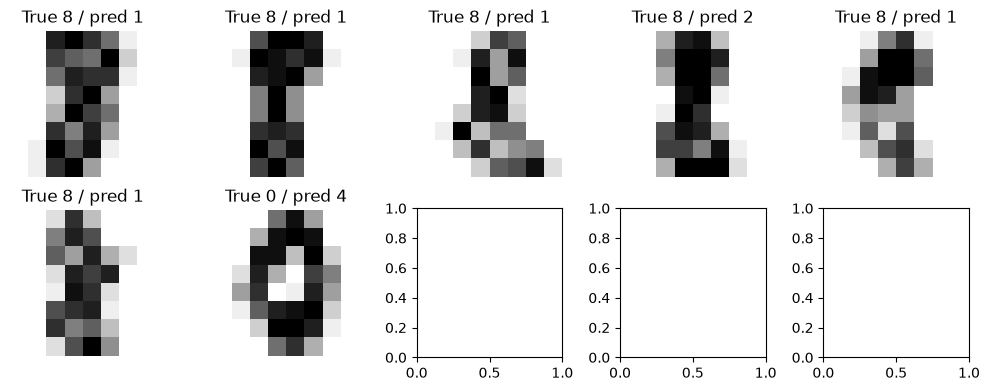

Most common class confusions (true -> predicted): [(np.int64(5), 8, 1), (np.int64(1), 8, 2), (np.int64(1), 0, 4), (np.int64(0), 9, 8), (np.int64(0), 9, 7)]


In [6]:
selected_model.eval()
with torch.no_grad(): test_logits = selected_model(X_test.to(device)); y_pred = test_logits.argmax(1).cpu().numpy()
print(f'Final test accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, digits=3, zero_division=0))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Test confusion matrix'); plt.show()
errors = np.flatnonzero(y_pred != y_test)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, errors[:10]): ax.imshow(digits.images[np.where((y == y_test[idx]) & (X[:, 0] == X_test_raw[idx, 0]))[0][0]] if False else X_test_raw[idx].reshape(8, 8), cmap='gray_r'); ax.set_title(f'True {y_test[idx]} / pred {y_pred[idx]}'); ax.axis('off')
plt.tight_layout(); plt.show()
if len(errors):
    pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
    print('Most common class confusions (true -> predicted):', sorted(pairs, reverse=True)[:5])
else: print('No errors on the held-out test split.')

## 7. Improve, save, and run inference
A possible improvement is collecting more diverse examples or using a CNN that preserves local pixel structure. Here we save the validation-selected model's weights and configuration. Inference applies the same [0, 1] scaling used during training.

Error interpretation: visually similar handwritten shapes (such as 3/5 or 4/9) can overlap; an 8×8 raster loses fine stroke detail. If train accuracy is high while validation/test is lower, investigate overfitting; if all are weak, increase training or revisit preprocessing/capacity. Check which classes dominate the confusion matrix before choosing a targeted improvement.

In [7]:
checkpoint = {'model_state_dict': selected_model.cpu().state_dict(), 'config': best_run['config'], 'input_scale': 'divide pixels by 16'}
torch.save(checkpoint, 'deep_learning_digits_model.pth')
example = torch.tensor(X_test_raw[:1], dtype=torch.float32)
with torch.no_grad(): predicted_digit = selected_model(example).argmax(1).item()
print('Saved deep_learning_digits_model.pth; example prediction:', predicted_digit, '| true:', int(y_test[0]))

Saved deep_learning_digits_model.pth; example prediction: 6 | true: 6
